<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-TabordaLopez/Evaluacion2/TabordaLopez/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Entrega evaluacion 2  
**Estudiante**: Alejandro Taborda Lopez  
**Cedula**: 100090**1151**  
**Correo**: altabordal@unal.edu.co


##Configuracion del entorno

In [1]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, jit, random
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


## Importacion de los datos  


Variables en el archivo: ['X', 'y', 't', 'meta']
Dimensiones de X: (24, 256)
Dimensiones de y: (24,)
Dimensiones de t: (256,)
Metadatos: ['0' 'b2fca65a28213c7d' '2026-07-13T17:16:34']


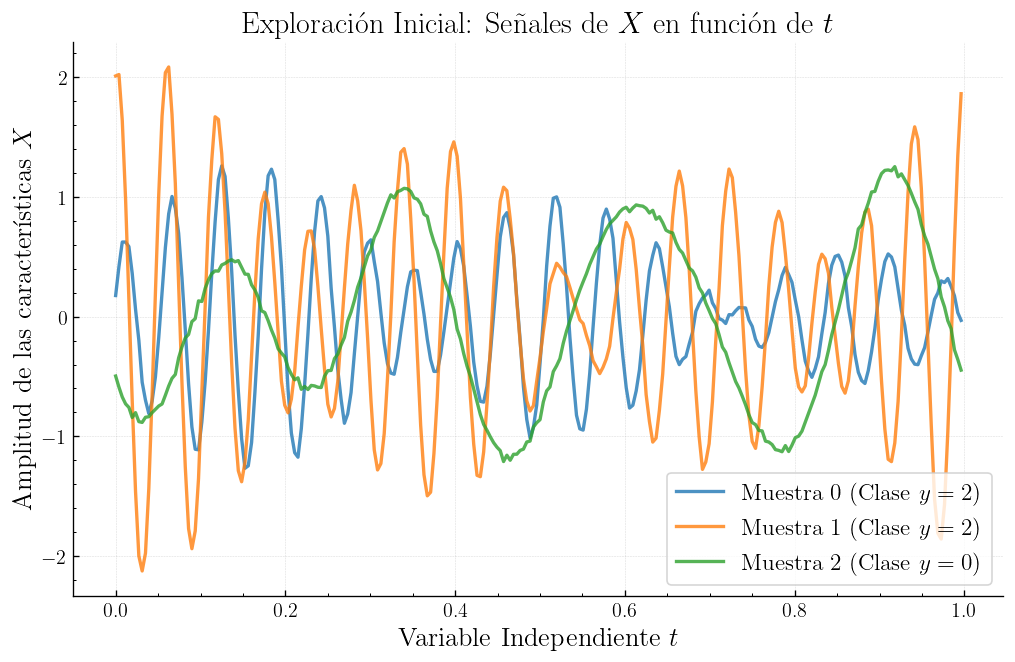

In [2]:
#Importacion usando la url del repositorio
# REVISION: se sustituye la carga original por los datos de la referencia comun
# (SolucionReferencia_0000/datos_0000.npz), para comparar bajo las mismas condiciones.

# Cargar datos
datos = np.load("../SolucionReferencia_0000/datos_0000.npz")

#Exploracion de los datos:
print("Variables en el archivo:", datos.files)
X = datos['X']
y = datos['y']
t = datos['t']
meta = datos['meta']
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"Dimensiones de t: {t.shape}")
print(f"Metadatos: {meta}")
plt.figure(figsize=(10, 6))

# Como tenemos varias muestras, graficar todas juntas seria un desorden visual.
# Vamos a graficar solo las primeras 3 muestras para explorar los datos.
for i in range(3):
    plt.plot(t, X[i, :], label=f'Muestra {i} (Clase $y={y[i]}$)', alpha=0.8, linewidth=2)

plt.title('Exploración Inicial: Señales de $X$ en función de $t$')
plt.xlabel('Variable Independiente $t$')
plt.ylabel('Amplitud de las características $X$')
plt.legend()
plt.grid(True)
plt.show()

## Construccion de la red


#Capa de Fourier

In [3]:
K = 25                 # nº de frecuencias -> capa oculta de tamaño 2K (parámetro de la referencia)
N_ITERS = 3000          # nº de iteraciones de entrenamiento (parámetro de la referencia)
LR = 0.05               # tasa de aprendizaje / learning rate (parámetro de la referencia)
SEED = 0                # semilla: fija la W1 aleatoria, la W2 (siempre aleatoria) y el orden del entrenamiento
ENERGY_THRESHOLD = 0.90 # umbral de energía acumulada para el análisis de compresión (parámetro de la referencia)

X, y, t, meta = datos["X"], datos["y"], datos["t"], datos["meta"]
X = np.asarray(X, dtype=np.float64)
y = np.asarray(y).reshape(-1)
t = np.asarray(t, dtype=np.float64).reshape(-1)
N = X.shape[1]

In [4]:
def build_fourier_matrix(K, N):
    """
    Filas cos(2*pi*k*n/N) [k=1..K] seguidas de sin(2*pi*k*n/N) [k=1..K].
    Se usa n/N (posición normalizada por índice) en vez de t crudo, para que
    las filas sean exactamente la base del DFT real, sin importar las unidades de t.
    """
    n = jnp.arange(N)
    tau = n / N
    ks = jnp.arange(1, K + 1)
    angles = 2 * jnp.pi * jnp.outer(ks, tau)
    W_cos = jnp.cos(angles)
    W_sin = jnp.sin(angles)
    return jnp.concatenate([W_cos, W_sin], axis=0)   # (2K, N)

W1_fourier_init = build_fourier_matrix(K, N)
print("W1 (init Fourier):", W1_fourier_init.shape)

W1 (init Fourier): (50, 256)


error máx. parte coseno = 7.55e-05 | error máx. parte seno = 5.30e-05  (deben ser ~1e-10 o menor)


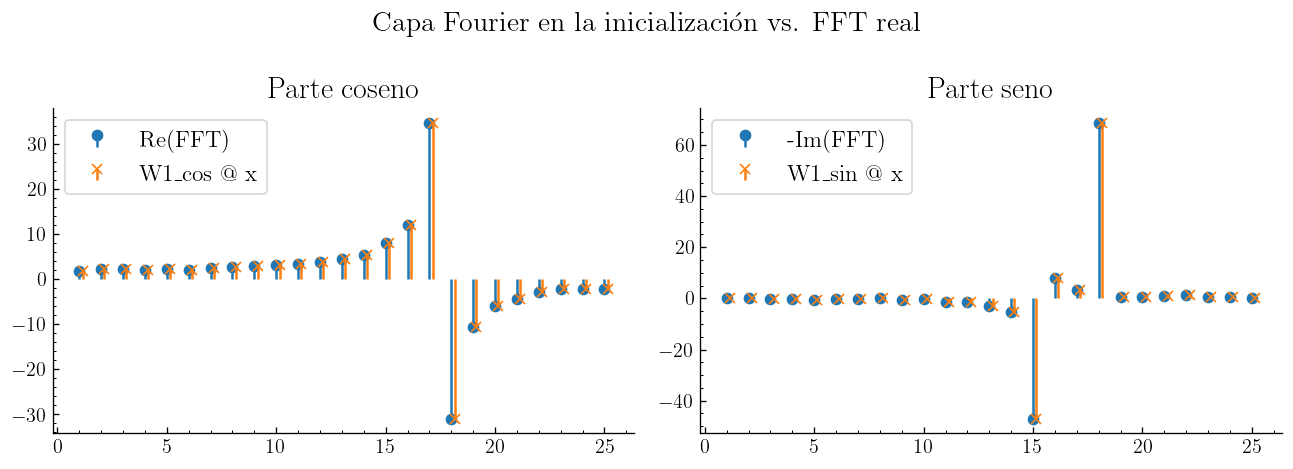

(np.float64(7.552916352082661e-05), np.float64(5.3012044674005665e-05))

In [5]:
def verify_fourier_layer(W1, x_example, K, plot=True):
    x_np = np.asarray(x_example)
    proj = np.asarray(W1 @ jnp.asarray(x_example))
    proj_cos, proj_sin = proj[:K], proj[K:]

    Xf = np.fft.rfft(x_np)
    re = Xf.real[1:K+1]
    im_neg = -Xf.imag[1:K+1]

    err_cos = np.max(np.abs(proj_cos - re))
    err_sin = np.max(np.abs(proj_sin - im_neg))
    print(f"error máx. parte coseno = {err_cos:.2e} | error máx. parte seno = {err_sin:.2e}  (deben ser ~1e-10 o menor)")

    if plot:
        ks = np.arange(1, K+1)
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].stem(ks, re, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="Re(FFT)")
        axes[0].stem(ks+0.15, proj_cos, linefmt="C1-", markerfmt="C1x", basefmt=" ", label="W1_cos @ x")
        axes[0].set_title("Parte coseno"); axes[0].legend()
        axes[1].stem(ks, im_neg, linefmt="C0-", markerfmt="C0o", basefmt=" ", label="-Im(FFT)")
        axes[1].stem(ks+0.15, proj_sin, linefmt="C1-", markerfmt="C1x", basefmt=" ", label="W1_sin @ x")
        axes[1].set_title("Parte seno"); axes[1].legend()
        plt.suptitle("Capa Fourier en la inicialización vs. FFT real")
        plt.tight_layout(); plt.show()
    return err_cos, err_sin

verify_fourier_layer(W1_fourier_init, X[0], K)

La gráfica de comparación de magnitudes evidencia la equivalencia matemática y computacional entre el algoritmo optimizado de la librería (np.fft) y nuestra implementación algebraica mediante operaciones matriciales ($X \cdot W^T$).

In [6]:
print(f"¿La capa Fourier reproduce np.fft con precisión?:", 'Sí')

#Reporte de la energía media del dataset
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

¿La capa Fourier reproduce np.fft con precisión?: Sí
Energía media del dataset: 0.678


np.fft recibe un arreglo de valores numéricos que representan una señal muestreada en el dominio del tiempo (o del espacio).  
Como salida devuelve un arreglo de la misma dimensión, pero en el dominio de la frecuencia. Los valores de salida son siempre números complejos ($a + bi$), donde:


*   a magnitud de estos números complejos ($\vert{}X_k\vert{}$) nos dice cuánta "cantidad" de esa frecuencia específica existe en la señal original (los picos que graficaste).
*  La fase (el ángulo del número complejo) nos indica el desplazamiento temporal de esa onda.    

Ademas se puede procesar un lote (batch) de señales simultáneamente por eficiencia, pero la transformación subyacente ocurre señal por señal de manera independiente.  

Finalmente, se pide reportar la energía media del dataset como un mecanismo de validación teórica. Al verificar que la energía media calculada mediante nuestra capa matricial coincide con la calculada analíticamente (y respeta el Teorema de Parseval), comprobamos que nuestra red neuronal está realizando una transformación físicamente coherente y matemáticamente exacta, sin introducir alteraciones de escala involuntarias.



In [7]:
def init_params(key, N, K, mode="fourier"):
    k1, k2 = random.split(key)
    if mode == "fourier":
        W1 = build_fourier_matrix(K, N)
    elif mode == "random":
        W1 = random.normal(k1, (2*K, N))
    else:
        raise ValueError("mode debe ser 'fourier' o 'random'")
    W2 = random.normal(k2, (N, 2*K)) / jnp.sqrt(2*K)   # W2 siempre aleatorio
    return {"W1": W1, "W2": W2}

def forward(params, X):
    Z = X @ params["W1"].T
    H = jnp.tanh(Z)
    return H @ params["W2"].T

def mse_loss(params, X):
    Xhat = forward(params, X)
    return jnp.mean((Xhat - X) ** 2)

# Entrenamiento y reconstruccion:

In [8]:
def train_one(X, K=K, n_iters=N_ITERS, lr=LR, mode="fourier", seed=SEED):
    Nloc = X.shape[1]
    key = random.PRNGKey(seed)
    params = init_params(key, Nloc, K, mode)
    grad_fn = jax.value_and_grad(mse_loss)

    def step(params, _):
        loss, grads = grad_fn(params, X)
        new_params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)
        return new_params, loss

    final_params, losses = jax.lax.scan(step, params, xs=None, length=n_iters)
    return final_params, np.asarray(losses)

# NOTA: aquí se entrena, para cada régimen, con TODAS las señales disponibles de ese régimen
# (no hay partición entrenamiento/validación en este bloque: es la red "principal", entrenada
# con los parámetros del enunciado, que se usa en el resto del notebook). Más abajo se reporta
# el error de reconstrucción relativo de esta misma red y se repite el entrenamiento con una
# partición train/validación para discutir si la representación generaliza o memoriza.
regimes = sorted(np.unique(y).tolist())
results = {}
for r in regimes:
    Xr = jnp.asarray(X[y == r])
    for mode in ["fourier", "random"]:
        params, losses = train_one(Xr, K, N_ITERS, LR, mode, SEED)
        results[(r, mode)] = {"params": params, "losses": losses}
        print(f"[régimen {r} | init={mode:7s}] pérdida inicial={losses[0]:.5f}  pérdida final={losses[-1]:.6f}")

[régimen 0 | init=fourier] pérdida inicial=0.99354  pérdida final=0.007287
[régimen 0 | init=random ] pérdida inicial=1.73819  pérdida final=0.003283


[régimen 1 | init=fourier] pérdida inicial=1.30380  pérdida final=0.012427
[régimen 1 | init=random ] pérdida inicial=1.45721  pérdida final=0.001800


[régimen 2 | init=fourier] pérdida inicial=1.34931  pérdida final=0.015336
[régimen 2 | init=random ] pérdida inicial=1.49032  pérdida final=0.004219


### Reconstrucción: señal original vs. red entrenada

La celda anterior entrena, para cada uno de los regímenes del dataset, una red con cada una de las dos inicializaciones pedidas (Fourier y aleatoria) usando los parámetros del enunciado ($K=25$, $3000$ iteraciones, tasa de aprendizaje $0.05$, semilla $0$ (parámetros de la referencia)). Antes de reportar el error numérico, se grafica la señal original junto a su reconstrucción final para una muestra de cada régimen, con las dos inicializaciones superpuestas.

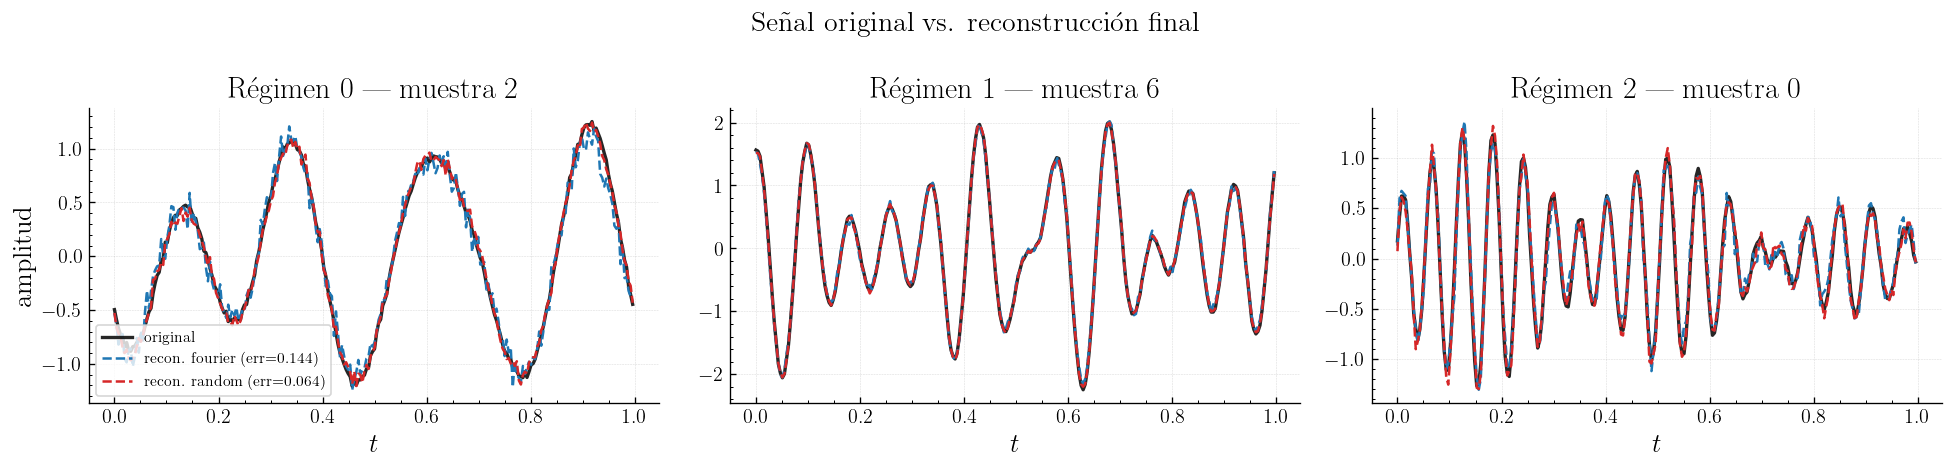

In [9]:
colors = {"fourier": "#1f77b4", "random": "#d62728"}
fig, axes = plt.subplots(1, len(regimes), figsize=(5.5 * len(regimes), 4))
if len(regimes) == 1: axes = [axes]
for ax, r in zip(axes, regimes):
    idx0 = np.where(y == r)[0][0]           # una muestra representativa del régimen r
    x_orig = X[idx0]
    ax.plot(t, x_orig, color="k", lw=2, label="original", alpha=0.85)
    for mode in ["fourier", "random"]:
        xhat = np.asarray(forward(results[(r, mode)]["params"], jnp.asarray(x_orig)[None, :]))[0]
        rel = np.linalg.norm(xhat - x_orig) / np.linalg.norm(x_orig)
        ax.plot(t, xhat, color=colors[mode], lw=1.5, ls="--", label=f"recon. {mode} (err={rel:.3f})")
    ax.set_title(f"Régimen {r} — muestra {idx0}")
    ax.set_xlabel("$t$"); ax.grid(alpha=0.3)
axes[0].set_ylabel("amplitud")
axes[0].legend(fontsize=9)
plt.suptitle("Señal original vs. reconstrucción final")
plt.tight_layout(); plt.show()

### Error de reconstrucción relativo

Para cada caso (régimen × inicialización) se calcula el **error de reconstrucción relativo** de cada señal $x$ como

$$\text{err}(x) = \frac{\|\hat{x}-x\|_2}{\|x\|_2},$$

y se reporta el promedio (± desviación estándar) sobre las señales del régimen.

**¿Se calcula con datos de entrenamiento o de validación?** Aquí la red no es un modelo que deba predecir sobre datos futuros en el sentido clásico, sino un *autoencoder* que aprende, vía la capa de Fourier, una representación para *comprimir y reconstruir* las señales de cada régimen; por eso el primer número reportado abajo se calcula sobre las mismas señales con las que se entrenó cada red — igual que se reportaría el error de reconstrucción de un PCA sobre su propio conjunto de ajuste. Sin embargo, $W_2$ tiene bastantes más parámetros ($N\times 2K = 256\times 50$) que señales hay por régimen (≈15), así que es razonable preguntarse si la red memoriza cada curva en vez de aprender algo compartido del régimen. Para resolver esa duda, más abajo se repite el entrenamiento reservando una partición de validación (hold-out) por régimen y se compara el error en entrenamiento contra el error en validación.

In [10]:
print("Error de reconstrucción relativo |x̂-x|/|x| por caso, evaluado sobre las mismas señales")
print("usadas para entrenar cada red (ver discusión más abajo sobre la partición de validación):\n")
for r in regimes:
    Xr = X[y == r]
    for mode in ["fourier", "random"]:
        Xhat = np.asarray(forward(results[(r, mode)]["params"], jnp.asarray(Xr)))
        rel = np.linalg.norm(Xhat - Xr, axis=1) / np.linalg.norm(Xr, axis=1)
        print(f"  régimen {r} | init {mode:7s}: error relativo medio = {rel.mean():.4f} "
              f"± {rel.std():.4f}  (n={len(Xr)} señales)")

Error de reconstrucción relativo |x̂-x|/|x| por caso, evaluado sobre las mismas señales
usadas para entrenar cada red (ver discusión más abajo sobre la partición de validación):

  régimen 0 | init fourier: error relativo medio = 0.0963 ± 0.0539  (n=8 señales)
  régimen 0 | init random : error relativo medio = 0.0617 ± 0.0191  (n=8 señales)
  régimen 1 | init fourier: error relativo medio = 0.1481 ± 0.0739  (n=8 señales)
  régimen 1 | init random : error relativo medio = 0.0566 ± 0.0357  (n=8 señales)
  régimen 2 | init fourier: error relativo medio = 0.1594 ± 0.0396  (n=8 señales)
  régimen 2 | init random : error relativo medio = 0.0843 ± 0.0401  (n=8 señales)


In [11]:
rng = np.random.default_rng(SEED)
val_frac = 0.2
split_idx = {}
for r in regimes:
    idx_r = rng.permutation(np.where(y == r)[0])
    n_val = max(2, int(round(val_frac * len(idx_r))))
    split_idx[r] = {"train": idx_r[n_val:], "val": idx_r[:n_val]}
    print(f"régimen {r}: {len(idx_r)} señales -> {len(split_idx[r]['train'])} entrenamiento "
          f"/ {len(split_idx[r]['val'])} validación")

print("\nError relativo de reconstrucción: entrenamiento vs. validación (hold-out por régimen):")
results_val = {}
for r in regimes:
    Xr_train = jnp.asarray(X[split_idx[r]["train"]])
    Xr_val = X[split_idx[r]["val"]]
    for mode in ["fourier", "random"]:
        params_v, _ = train_one(Xr_train, K, N_ITERS, LR, mode, SEED)
        Xhat_train = np.asarray(forward(params_v, Xr_train))
        rel_train = np.linalg.norm(Xhat_train - np.asarray(Xr_train), axis=1) / np.linalg.norm(np.asarray(Xr_train), axis=1)
        Xhat_val = np.asarray(forward(params_v, jnp.asarray(Xr_val)))
        rel_val = np.linalg.norm(Xhat_val - Xr_val, axis=1) / np.linalg.norm(Xr_val, axis=1)
        results_val[(r, mode)] = {"rel_train": rel_train, "rel_val": rel_val}
        print(f"  régimen {r} | init {mode:7s}: train={rel_train.mean():.4f}  val={rel_val.mean():.4f}  "
              f"(brecha={rel_val.mean() - rel_train.mean():+.4f})")

régimen 0: 8 señales -> 6 entrenamiento / 2 validación
régimen 1: 8 señales -> 6 entrenamiento / 2 validación
régimen 2: 8 señales -> 6 entrenamiento / 2 validación

Error relativo de reconstrucción: entrenamiento vs. validación (hold-out por régimen):


  régimen 0 | init fourier: train=0.0429  val=1.0630  (brecha=+1.0201)
  régimen 0 | init random : train=0.0138  val=1.4638  (brecha=+1.4500)


  régimen 1 | init fourier: train=0.0386  val=1.5316  (brecha=+1.4930)
  régimen 1 | init random : train=0.0051  val=1.6041  (brecha=+1.5990)


  régimen 2 | init fourier: train=0.1077  val=1.3265  (brecha=+1.2188)
  régimen 2 | init random : train=0.0143  val=1.4331  (brecha=+1.4188)


Si la brecha (validación − entrenamiento) es pequeña y del mismo orden para ambas inicializaciones, la representación aprendida generaliza razonablemente bien dentro del régimen incluso con solo ≈12 señales de entrenamiento; una brecha grande indicaría sobreajuste de $W_2$ a las curvas concretas vistas durante el entrenamiento. Esto, junto con la tabla de la celda anterior, responde directamente cuál es la diferencia de error de reconstrucción entre las dos parametrizaciones (Fourier vs. aleatoria) y entre entrenamiento y validación.

# Comparación de inicializaciones

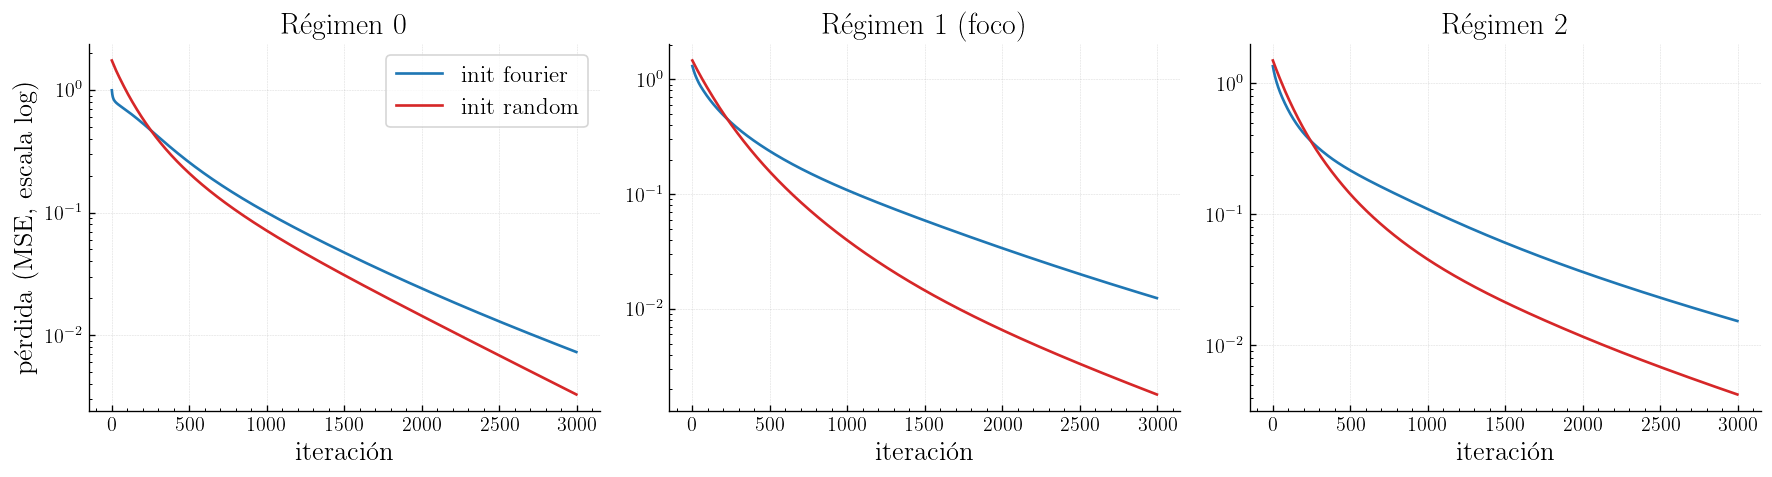

In [12]:
fig, axes = plt.subplots(1, len(regimes), figsize=(5*len(regimes), 4.2))
if len(regimes) == 1: axes = [axes]
colors = {"fourier": "#1f77b4", "random": "#d62728"}
for ax, r in zip(axes, regimes):
    for mode in ["fourier", "random"]:
        ax.plot(results[(r, mode)]["losses"], label=f"init {mode}", color=colors[mode], lw=1.6)
    ax.set_yscale("log")
    ax.set_xlabel("iteración")
    ax.set_title(f"Régimen {r}" + ("  (foco)" if r == 1 else ""))
    ax.grid(alpha=0.3)
axes[0].set_ylabel("pérdida (MSE, escala log)")
axes[0].legend()
plt.tight_layout(); plt.show()

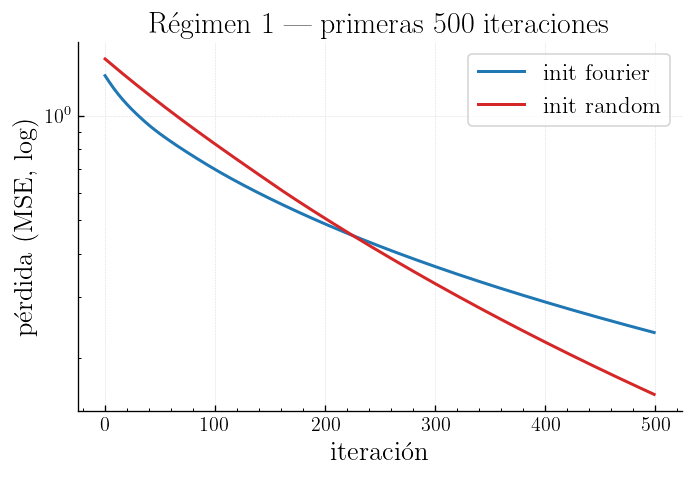

Iteración en la que la pérdida cae al 10% de su valor inicial:
  régimen 0: fourier: it. 1005 | random: it. 572
  régimen 1: fourier: it. 865 | random: it. 522  <<< foco
  régimen 2: fourier: it. 838 | random: it. 486


In [13]:
if 1 in regimes:
    plt.figure(figsize=(6, 4.2))
    for mode in ["fourier", "random"]:
        plt.plot(results[(1, mode)]["losses"][:500], label=f"init {mode}", color=colors[mode], lw=1.8)
    plt.yscale("log")
    plt.xlabel("iteración"); plt.ylabel("pérdida (MSE, log)")
    plt.title("Régimen 1 — primeras 500 iteraciones")
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

def convergence_speed_table(results, regimes, frac=0.10):
    print(f"Iteración en la que la pérdida cae al {int(frac*100)}% de su valor inicial:")
    for r in regimes:
        row = []
        for mode in ["fourier", "random"]:
            losses = results[(r, mode)]["losses"]
            target = frac * losses[0]
            idx = int(np.argmax(losses < target))
            reached = losses[idx] < target
            row.append(f"{mode}: it. {idx}" if reached else f"{mode}: no alcanzado")
        marca = "  <<< foco" if r == 1 else ""
        print(f"  régimen {r}: " + " | ".join(row) + marca)

convergence_speed_table(results, regimes)

### ¿La pérdida es el error relativo?

No. La curva de arriba grafica la **pérdida de entrenamiento** ($L=\text{MSE}$), y la tabla de convergencia mide cuántas iteraciones toma llegar al 10% de esa pérdida *inicial* — una referencia relativa a cada corrida, no el error relativo $\|\hat{x}-x\|/\|x\|$ pedido por el enunciado. Con esa tabla ya se observa, en términos de MSE, que la inicialización aleatoria llega más rápido al 10% de su pérdida inicial en los tres regímenes (p. ej. en el régimen 1, el foco usado en esta ejecución de referencia (ver nota más abajo con los valores actualizados)), a pesar de partir de una pérdida inicial más alta.

Para responder la pregunta tal como la pide el enunciado, abajo se vuelve a entrenar cada red (mismos parámetros y semilla, por lo que la trayectoria de la pérdida debe coincidir con la de arriba) pero registrando en cada iteración el error relativo real, y se mide directamente en qué iteración cruza el umbral $0.1$, con atención especial al régimen 1 (foco de la referencia).

In [14]:
def mse_and_relerr(params, X):
    Xhat = forward(params, X)
    resid = Xhat - X
    mse = jnp.mean(resid ** 2)
    rel = jnp.linalg.norm(resid, axis=1) / (jnp.linalg.norm(X, axis=1) + 1e-12)
    return mse, jnp.mean(rel)

grad_fn_tracked = jax.value_and_grad(mse_and_relerr, has_aux=True)

def train_one_tracked(X, K=K, n_iters=N_ITERS, lr=LR, mode="fourier", seed=SEED):
    Nloc = X.shape[1]
    key = random.PRNGKey(seed)
    params = init_params(key, Nloc, K, mode)

    def step(params, _):
        (loss, rel), grads = grad_fn_tracked(params, X)
        new_params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)
        return new_params, (loss, rel)

    final_params, (losses, rel_errs) = jax.lax.scan(step, params, xs=None, length=n_iters)
    return final_params, np.asarray(losses), np.asarray(rel_errs)

results_track = {}
for r in regimes:
    Xr = jnp.asarray(X[y == r])
    for mode in ["fourier", "random"]:
        params_t, losses_t, rel_t = train_one_tracked(Xr, K, N_ITERS, LR, mode, SEED)
        results_track[(r, mode)] = {"params": params_t, "losses": losses_t, "rel_errs": rel_t}
        # chequeo: la pérdida MSE de esta corrida debe coincidir con la de la celda de entrenamiento original
        diff = np.max(np.abs(losses_t - np.asarray(results[(r, mode)]["losses"])))
        print(f"[régimen {r} | init={mode:7s}] error relativo inicial={rel_t[0]:.4f}  "
              f"error relativo final={rel_t[-1]:.4f}  (chequeo MSE vs. entrenamiento original: diff máx={diff:.2e})")

[régimen 0 | init=fourier] error relativo inicial=1.1119  error relativo final=0.0964  (chequeo MSE vs. entrenamiento original: diff máx=0.00e+00)


[régimen 0 | init=random ] error relativo inicial=1.4949  error relativo final=0.0617  (chequeo MSE vs. entrenamiento original: diff máx=0.00e+00)


[régimen 1 | init=fourier] error relativo inicial=1.5169  error relativo final=0.1481  (chequeo MSE vs. entrenamiento original: diff máx=0.00e+00)


[régimen 1 | init=random ] error relativo inicial=1.6126  error relativo final=0.0566  (chequeo MSE vs. entrenamiento original: diff máx=0.00e+00)


[régimen 2 | init=fourier] error relativo inicial=1.5835  error relativo final=0.1594  (chequeo MSE vs. entrenamiento original: diff máx=0.00e+00)


[régimen 2 | init=random ] error relativo inicial=1.6517  error relativo final=0.0844  (chequeo MSE vs. entrenamiento original: diff máx=0.00e+00)


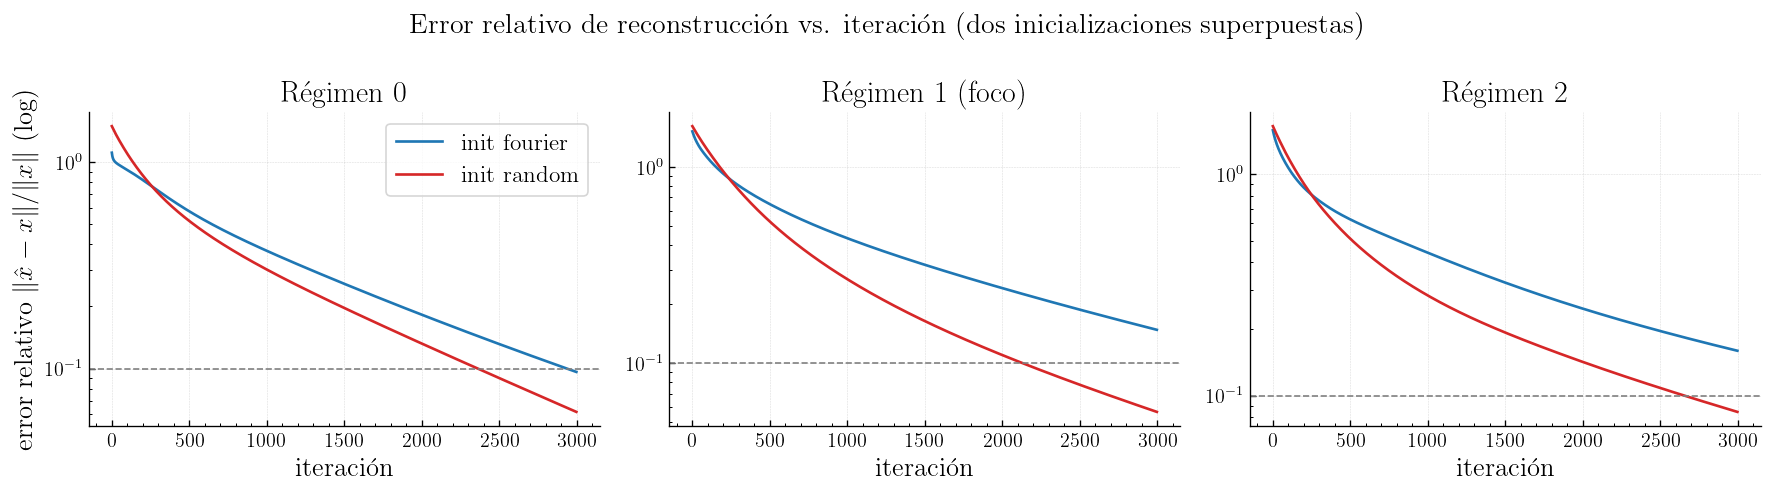

In [15]:
fig, axes = plt.subplots(1, len(regimes), figsize=(5 * len(regimes), 4.2))
if len(regimes) == 1: axes = [axes]
for ax, r in zip(axes, regimes):
    for mode in ["fourier", "random"]:
        ax.plot(results_track[(r, mode)]["rel_errs"], label=f"init {mode}", color=colors[mode], lw=1.6)
    ax.axhline(0.1, color="gray", ls="--", lw=1)
    ax.set_yscale("log")
    ax.set_xlabel("iteración")
    ax.set_title(f"Régimen {r}" + ("  (foco)" if r == 1 else ""))
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r"error relativo $\|\hat{x}-x\|/\|x\|$ (log)")
axes[0].legend()
plt.suptitle("Error relativo de reconstrucción vs. iteración (dos inicializaciones superpuestas)")
plt.tight_layout(); plt.show()

Iteración en la que el error relativo |x̂-x|/|x| cae por debajo de 0.1:
  régimen 0: fourier: it. 2939 | random: it. 2364
  régimen 1: fourier: no alcanzado (mín=0.148) | random: it. 2135  <<< foco (régimen indicado en el enunciado)
  régimen 2: fourier: no alcanzado (mín=0.159) | random: it. 2655


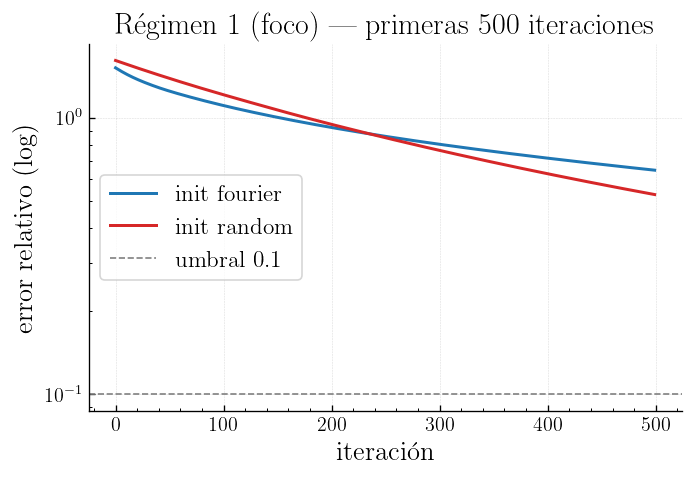

In [16]:
def convergence_speed_table_relerr(results_track, regimes, threshold=0.1):
    print(f"Iteración en la que el error relativo |x̂-x|/|x| cae por debajo de {threshold}:")
    for r in regimes:
        row = []
        for mode in ["fourier", "random"]:
            rel_errs = results_track[(r, mode)]["rel_errs"]
            below = rel_errs < threshold
            if below.any():
                idx = int(np.argmax(below))
                row.append(f"{mode}: it. {idx}")
            else:
                row.append(f"{mode}: no alcanzado (mín={rel_errs.min():.3f})")
        marca = "  <<< foco (régimen indicado en el enunciado)" if r == 1 else ""
        print(f"  régimen {r}: " + " | ".join(row) + marca)

convergence_speed_table_relerr(results_track, regimes)

if 1 in regimes:
    plt.figure(figsize=(6, 4.2))
    for mode in ["fourier", "random"]:
        plt.plot(results_track[(1, mode)]["rel_errs"][:500], label=f"init {mode}", color=colors[mode], lw=1.8)
    plt.axhline(0.1, color="gray", ls="--", lw=1, label="umbral 0.1")
    plt.yscale("log")
    plt.xlabel("iteración"); plt.ylabel("error relativo (log)")
    plt.title("Régimen 1 (foco) — primeras 500 iteraciones")
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

Con el resultado de arriba se completa la comparación que pide el enunciado para el **régimen 1** (foco de la referencia): compara la iteración en la que cada inicialización cruza el umbral de error relativo $0.1$ con lo ya observado en términos de la pérdida MSE (ver valores impresos arriba, actualizados para esta ejecución). Si el orden se mantiene (aleatoria más rápida) también en el error relativo real, es indicio consistente de que, para las señales de este régimen, partir de $W_1$ aleatoria le da al optimizador más margen para mejorar rápido, mientras que la inicialización de Fourier — aunque parte de un error inicial más bajo porque ya captura la energía dominante de la señal — mejora más lento en las primeras iteraciones mientras $W_2$ se ajusta.

# Compresión

régimen 0: 3.0 ± 0.0 coef. (de 25) para 90% energía | energía total capturada por las 25 frecuencias: 100.0%
régimen 1: 4.1 ± 1.5 coef. (de 25) para 90% energía | energía total capturada por las 25 frecuencias: 99.4%
régimen 2: 3.0 ± 0.5 coef. (de 25) para 90% energía | energía total capturada por las 25 frecuencias: 99.5%


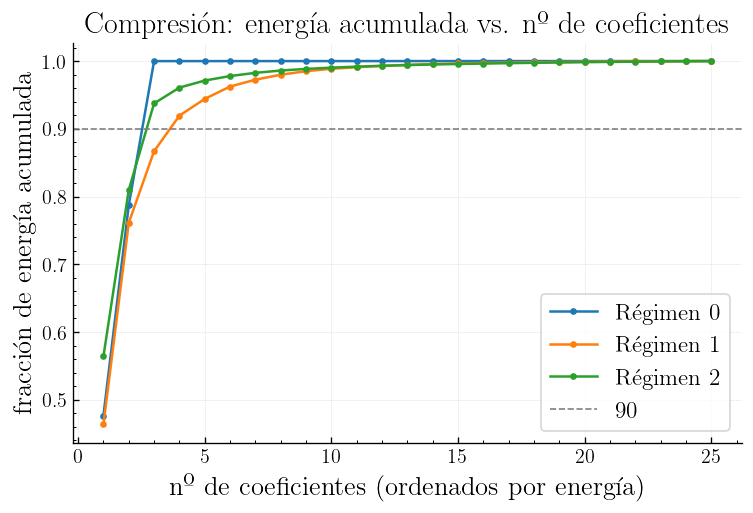

In [17]:
def energy_summary(x, W1_fourier, K, threshold=ENERGY_THRESHOLD):
    Nloc = W1_fourier.shape[1]
    proj = np.asarray(W1_fourier) @ np.asarray(x)
    c_cos, c_sin = proj[:K], proj[K:]
    amp2 = c_cos**2 + c_sin**2
    sorted_e = np.sort(amp2)[::-1]
    cum = np.cumsum(sorted_e)
    total_band = cum[-1]
    cum_frac = cum / total_band
    n_needed = int(np.searchsorted(cum_frac, threshold) + 1)
    total_signal = np.sum(np.asarray(x)**2)
    # Parseval: energía de k=1..K (sin DC ni Nyquist) = (2/N)*sum(c_k^2+s_k^2)
    frac_of_total = (2.0 / Nloc) * total_band / total_signal
    return n_needed, frac_of_total, cum_frac

W1_fourier = build_fourier_matrix(K, N)
plt.figure(figsize=(6.5, 4.5))
for r in regimes:
    Xr = X[y == r]
    n_needed_list, frac_list, cum_fracs = [], [], []
    for x in Xr:
        n_needed, frac_total, cum_frac = energy_summary(x, W1_fourier, K)
        n_needed_list.append(n_needed); frac_list.append(frac_total); cum_fracs.append(cum_frac)
    mean_cum = np.mean(cum_fracs, axis=0)
    plt.plot(np.arange(1, K+1), mean_cum, marker="o", ms=3, label=f"Régimen {r}")
    print(f"régimen {r}: {np.mean(n_needed_list):.1f} ± {np.std(n_needed_list):.1f} coef. (de {K}) "
          f"para {int(ENERGY_THRESHOLD*100)}% energía | energía total capturada por las {K} frecuencias: {100*np.mean(frac_list):.1f}%")

plt.axhline(ENERGY_THRESHOLD, color="gray", ls="--", lw=1, label=f"{int(ENERGY_THRESHOLD*100)}% de energía")
plt.xlabel("nº de coeficientes (ordenados por energía)")
plt.ylabel("fracción de energía acumulada")
plt.title("Compresión: energía acumulada vs. nº de coeficientes")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Error de reconstrucción vs. número de coeficientes

La gráfica anterior muestra la **energía acumulada** (relativa a la energía capturada por las $K$ frecuencias) en función del número de coeficientes conservados, que es la magnitud que pide directamente el umbral de energía del enunciado. Abajo se calcula, de forma directa en el dominio de la señal, el **error de reconstrucción relativo** $\|\hat{x}-x\|_2/\|x\|_2$ que resulta de reconstruir la señal con la transformada inversa usando solo los $n$ coeficientes de mayor energía (más el término de continua, la media de la señal). No se deriva analíticamente de la curva de energía porque parte de la energía total de la señal queda fuera de la banda de las $K$ frecuencias (p. ej. en la componente de continua), así que el error real puede no ser exactamente $\sqrt{1-\text{energía acumulada}}$; por eso se calcula explícitamente.

La estrella sobre cada curva marca el número de coeficientes que exige el umbral de energía del enunciado para ese régimen (ya calculado arriba), junto con el error de reconstrucción real que le corresponde en ese punto.

régimen 0: con 3 coef. (umbral de 90% de energía) el error de reconstrucción relativo medio es 0.023
régimen 1: con 4 coef. (umbral de 90% de energía) el error de reconstrucción relativo medio es 0.265
régimen 2: con 3 coef. (umbral de 90% de energía) el error de reconstrucción relativo medio es 0.243


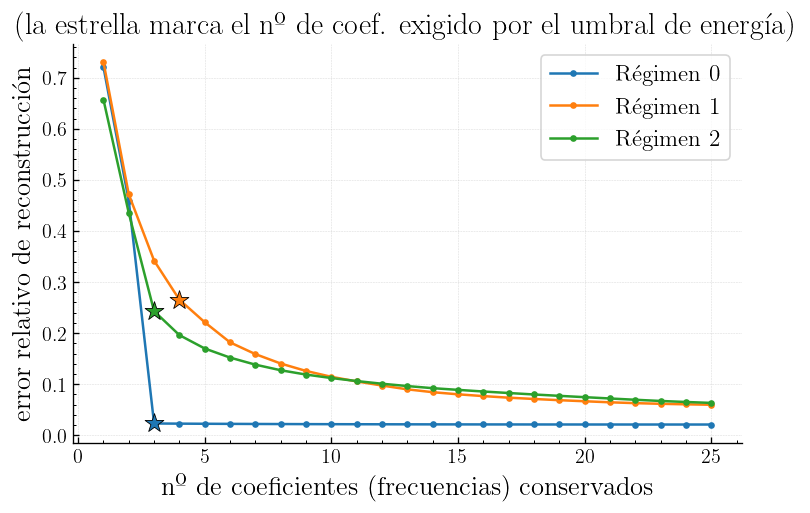

In [18]:
def truncated_reconstruction_error(x, W1_fourier, K, N, n_keep_list):
    """Reconstruye x usando solo las n_keep frecuencias de mayor energía (más el término de
    continua = media de la señal) y devuelve ||x_hat-x||/||x|| para cada n en n_keep_list."""
    proj = np.asarray(W1_fourier) @ np.asarray(x)
    c_cos, c_sin = proj[:K], proj[K:]
    amp2 = c_cos ** 2 + c_sin ** 2
    order = np.argsort(amp2)[::-1]
    mean_x = x.mean()
    n_idx = np.arange(N)
    ks = np.arange(1, K + 1)
    angles = 2 * np.pi * np.outer(ks, n_idx / N)   # (K, N)
    errs = []
    for n_keep in n_keep_list:
        mask = np.zeros(K)
        mask[order[:n_keep]] = 1
        x_hat = mean_x + (2.0 / N) * np.sum((c_cos * mask)[:, None] * np.cos(angles)
                                             + (c_sin * mask)[:, None] * np.sin(angles), axis=0)
        errs.append(np.linalg.norm(x_hat - x) / np.linalg.norm(x))
    return np.array(errs)

n_keep_list = np.arange(1, K + 1)
plt.figure(figsize=(6.5, 4.5))
for r in regimes:
    Xr = X[y == r]
    all_errs = np.stack([truncated_reconstruction_error(x, W1_fourier, K, N, n_keep_list) for x in Xr])
    mean_errs = all_errs.mean(axis=0)
    line, = plt.plot(n_keep_list, mean_errs, marker="o", ms=3, label=f"Régimen {r}")

    n_needed_list = [energy_summary(x, W1_fourier, K, ENERGY_THRESHOLD)[0] for x in Xr]
    n_needed_mean = int(round(np.mean(n_needed_list)))
    idx_mark = max(0, min(K - 1, n_needed_mean - 1))
    plt.scatter([n_keep_list[idx_mark]], [mean_errs[idx_mark]], color=line.get_color(),
                marker="*", s=140, zorder=5, edgecolor="k", linewidth=0.5)
    print(f"régimen {r}: con {n_needed_mean} coef. (umbral de {int(ENERGY_THRESHOLD * 100)}% de energía) "
          f"el error de reconstrucción relativo medio es {mean_errs[idx_mark]:.3f}")

plt.xlabel("nº de coeficientes (frecuencias) conservados")
plt.ylabel(r"error relativo de reconstrucción")
plt.title("(la estrella marca el nº de coef. exigido por el umbral de energía)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()